In [18]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

In [19]:
# Chargement
wolf_df = pd.read_csv('DenaliWolfPopulation.csv')
bird_df = pd.read_csv('sample_occurrence.csv', low_memory=False)

# Traitement des valeurs manquantes (1 signalement sans comptage explicite = au moins 1 individu)
bird_df['individualCount'] = bird_df['individualCount'].fillna(1)

# Calcul du nombre de signalements (lignes d'observations) par an
sightings_per_year = bird_df.groupby('year').size().reset_index(name='Nombre_Signalements')

# Calcul du total d'individus cumulés par an
individuals_per_year = bird_df.groupby('year')['individualCount'].sum().reset_index(name='Total_Individus')

# Fusion des métriques ornithologiques
bird_summary = pd.merge(sightings_per_year, individuals_per_year, on='year')

# Calcul du ratio : total individus cumulés / nombre de signalements
bird_summary['Bird_Ratio'] = bird_summary['Total_Individus'] / bird_summary['Nombre_Signalements']

# Fusion avec les données de loups
df = pd.merge(wolf_df, bird_summary, left_on='Year', right_on='year', how='inner')

# Extraction des variables (Variables brutes, sans standardisation)
wolves_x = df['Wolves_Counted_Fall'].values
birds_ratio_y = df['Bird_Ratio'].values

# Vérification des données
df[['Year', 'Wolves_Counted_Fall', 'Total_Individus', 'Nombre_Signalements', 'Bird_Ratio']].head()

,Year,Wolves_Counted_Fall,Total_Individus,Nombre_Signalements,Bird_Ratio
0,1986,22,7.0,7,1.000000
1,1988,121,15.0,10,1.500000
2,1989,127,16.0,6,2.666667
3,1990,136,75.0,36,2.083333
4,1991,137,14.0,10,1.400000


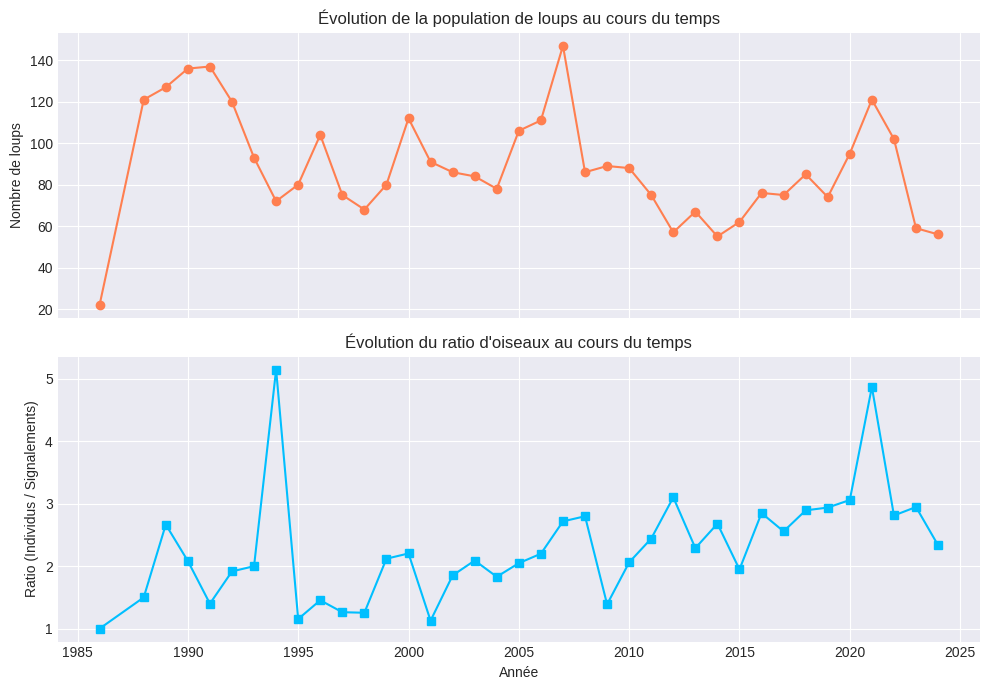

In [24]:
# 2. Graphiques séparés mais alignés temporellement
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Graphique du haut : Loups
ax1.plot(df['Year'], df['Wolves_Counted_Fall'], color='coral', marker='o', label='Loups')
ax1.set_ylabel('Nombre de loups')
ax1.set_title('Évolution de la population de loups au cours du temps')
ax1.grid(True)

# Graphique du bas : Oiseaux
ax2.plot(df['Year'], df['Bird_Ratio'], color='deepskyblue', marker='s', label='Ratio Oiseaux')
ax2.set_xlabel('Année')
ax2.set_ylabel('Ratio (Individus / Signalements)')
ax2.set_title("Évolution du ratio d'oiseaux au cours du temps")
ax2.grid(True)

plt.tight_layout()
plt.show()

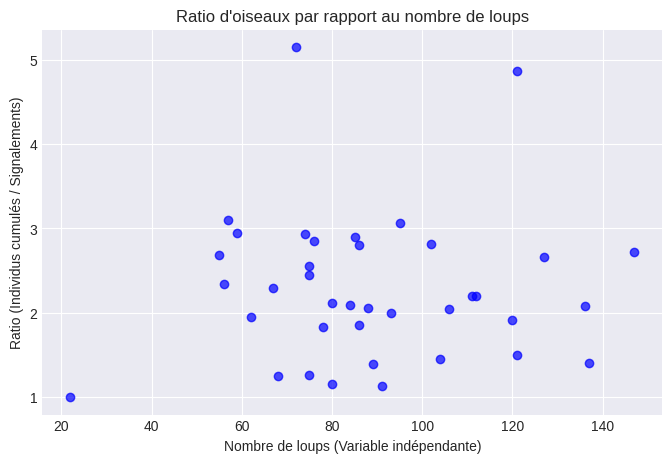

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(wolves_x, birds_ratio_y, color='blue', alpha=0.7)
plt.title("Ratio d'oiseaux par rapport au nombre de loups")
plt.xlabel("Nombre de loups (Variable indépendante)")
plt.ylabel("Ratio (Individus cumulés / Signalements)")
plt.show()

In [21]:
with pm.Model() as linear_model:
    # A priori (Priors) larges adaptés aux données non standardisées
    alpha = pm.Normal('alpha', mu=0, sigma=100) # Intercept
    beta = pm.Normal('beta', mu=0, sigma=10)    # Pente
    sigma = pm.HalfNormal('sigma', sigma=10)    # Bruit
    
    # Modèle linéaire (Moyenne)
    mu = alpha + beta * wolves_x
    
    # Vraisemblance (Likelihood) - Loi Normale car le ratio est une variable continue
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=birds_ratio_y)
    
    # Échantillonnage (MCMC)
    trace = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.9, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


/var/data/python/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,2.181,0.519,1.345,3.007,3095.680,3109.330,1.000,0.009,0.007
beta,0.001,0.006,-0.008,0.010,3056.044,3030.739,1.000,0.000,0.000
sigma,0.931,0.113,0.770,1.122,3740.982,3694.661,1.001,0.002,0.002


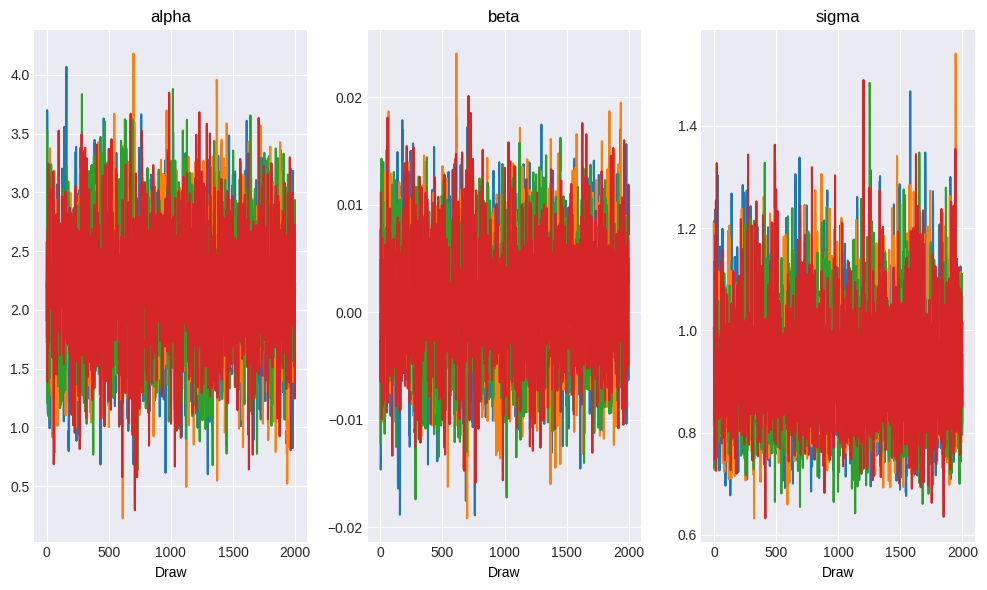

In [22]:
# Résumé statistique des paramètres estimés
display(az.summary(trace, round_to=3))

# Graphiques de trace adaptés à votre version d'ArviZ
az.plot_trace(trace, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

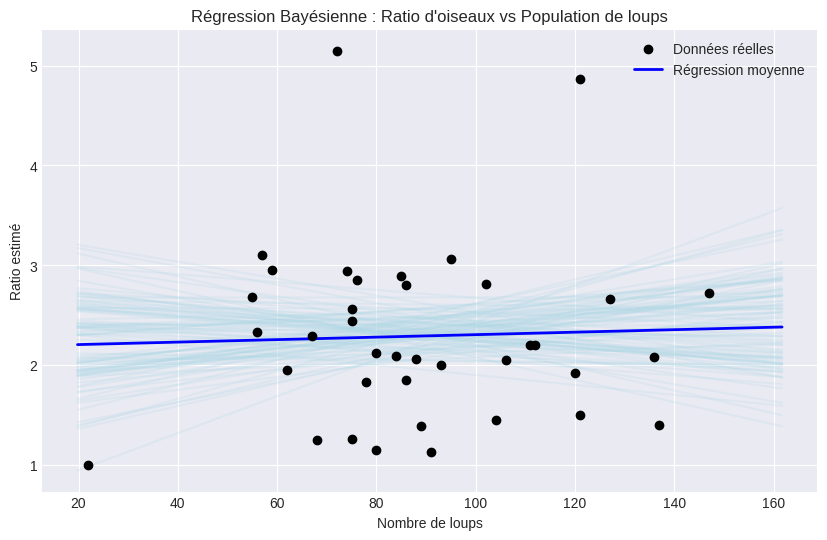

In [23]:
plt.figure(figsize=(10, 6))

# Tracé des données observées
plt.scatter(wolves_x, birds_ratio_y, color='black', label='Données réelles', zorder=5)

# Définition de l'axe X pour le tracé de la ligne
x_seq = np.linspace(wolves_x.min() * 0.9, wolves_x.max() * 1.1, 100)
alpha_samples = trace.posterior['alpha'].values.flatten()
beta_samples = trace.posterior['beta'].values.flatten()

# Tracé de l'incertitude (100 lignes tirées de la distribution a posteriori)
idx = np.random.choice(len(alpha_samples), 100, replace=False)
for i in idx:
    plt.plot(x_seq, alpha_samples[i] + beta_samples[i] * x_seq, color='lightblue', alpha=0.2)

# Tracé de la ligne de régression moyenne
mu_mean = alpha_samples.mean() + beta_samples.mean() * x_seq
plt.plot(x_seq, mu_mean, color='blue', lw=2, label='Régression moyenne')

plt.title("Régression Bayésienne : Ratio d'oiseaux vs Population de loups")
plt.xlabel("Nombre de loups")
plt.ylabel("Ratio estimé")
plt.legend()
plt.show()